# Блок 4 • Занятие 3 — вероятность, условная вероятность, независимость + симуляции (TODO)
**Дата:** 2026-03-02  
**Формат:** мини-теория → 10 кодовых ячеек → автопроверка (`assert`) → Run all  
**Цель занятия:** уметь считать **P(A)** и **P(A|B)** по таблице частот и проверять идею независимости через симуляции.

---

## Мини-теория (термины, особенности, синтаксис)

### 1) Событие и вероятность
- **Событие** — то, что может случиться (например, “пользователь купил”).
- **Вероятность P(A)** — число от 0 до 1: насколько событие “часто” происходит.

### 2) Условная вероятность
- **P(A|B)** — вероятность A при условии, что B уже случилось.  
Формула в частотах (самая важная для практики):
> P(A|B) = count(A ∩ B) / count(B)

### 3) Независимость
A и B независимы, если знание B не меняет шанс A:
> P(A|B) = P(A)

В реальных данных часто **не** так — и это важно для ML и аналитики.

### 4) Таблица сопряжённости (contingency table)
Это таблица частот для двух признаков, например:
- rows: “A случилось?” (0/1)
- cols: “B случилось?” (0/1)

### 5) Синтаксис Python, который будет сегодня
- `dict` для хранения частот
- `for` циклы
- `if` проверки
- `matplotlib` для наглядной визуализации
- `random` / `numpy.random` для симуляций

---

## Задача урока (перенос в VS Code)
Перенесите в проект (в конце занятия):
- `src/math_stats.py`: функции `prob_event`, `prob_conditional`, `is_independent_by_counts`
- (опционально) `src/analytics.py`: функция `contingency_table` для категорий


---
## Ячейка 1/10 — Данные как “события” (список записей)

**Идея**
Мы будем работать не с формулами, а с **частотами** из данных.

Запись = словарь с признаками, например:
- `clicked` (кликнул? 0/1)
- `bought` (купил? 0/1)

Так часто устроены логи и события в дипломах (бот/сервис/сайт).


In [20]:
records = [
    {"clicked": 0, "bought": 0}, {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 0}, {"clicked": 1, "bought": 1},
    {"clicked": 2, "bought": 1}, {"clicked": 2, "bought": 2},
    {"clicked": 2, "bought": 2}, {"clicked": 3, "bought": 1},
    {"clicked": 3, "bought": 2}, {"clicked": 3, "bought": 3},
    {"clicked": 3, "bought": 3}, {"clicked": 3, "bought": 3},
]

print("n =", len(records))
print("first record:", records[0])

n = 12
first record: {'clicked': 0, 'bought': 0}


---
## Ячейка 2/10 — Подсчёт частот (counts) через цикл `for`

**Что делаем**
Посчитаем:
- `count_clicked` — сколько кликнули
- `count_bought` — сколько купили
- `count_clicked_and_bought` — сколько и кликнули, и купили

**Синтаксис**
- `for r in records:` перебирает записи
- `if r["clicked"] == 1:` проверка условия


In [21]:
count_clicked = 0
count_bought = 0
count_clicked_and_bought = 0

for r in records:
    if r["clicked"] == 1:
        count_clicked += 1
    if r["bought"] == 1:
        count_bought += 1
    if r["clicked"] == 1 and r["bought"] == 1:
        count_clicked_and_bought += 1

print("count_clicked =", count_clicked)
print("count_bought =", count_bought)
print("count_clicked_and_bought =", count_clicked_and_bought)


count_clicked = 2
count_bought = 3
count_clicked_and_bought = 1


---
## Ячейка 3/10 — Вероятность события P(A) по частотам

**Формула частот**
P(A) = count(A) / n

Мы реализуем функцию `prob_event(count_A, n)`.

**Важно**
- если n=0 → ошибка (деление на ноль)


In [22]:
def prob_event(count_A: int, n: int) -> float:
    if n <= 0:
        raise ValueError("prob_event: n must be > 0")
    if count_A < 0 or count_A > n:
        raise ValueError("prob_event: invalid count")
    return count_A / n

n = len(records)
print("P(clicked) =", prob_event(count_clicked, n))
print("P(bought)  =", prob_event(count_bought, n))

P(clicked) = 0.16666666666666666
P(bought)  = 0.25


---
## Ячейка 4/10 — Условная вероятность P(A|B)

**Частотная формула**
P(A|B) = count(A ∩ B) / count(B)

Пример:
- A = bought=1
- B = clicked=1
Тогда P(bought|clicked) = count(clicked & bought) / count(clicked)

**Особенность**
Если count(B)=0, условная вероятность не определена → ошибка.


In [23]:
def prob_conditional(count_A_and_B: int, count_B: int) -> float:
    if count_B <= 0:
        raise ValueError("prob_conditional: count_B must be > 0")
    if count_A_and_B < 0 or count_A_and_B > count_B:
        raise ValueError("prob_conditional: invalid intersection count")
    return count_A_and_B / count_B

print("P(bought|clicked) =", prob_conditional(count_clicked_and_bought, count_clicked))

P(bought|clicked) = 0.5


---
## Ячейка 5/10 — Проверка независимости по частотам

Идея: A и B независимы, если P(A|B) ≈ P(A).

Мы сделаем функцию `is_independent_by_counts(p_a, p_a_given_b, tol=...)`.

**Особенность**
В данных всегда есть шум, поэтому сравниваем “примерно” (tolerance).


In [24]:
def is_independent_by_counts(p_a: float, p_a_given_b: float, tol: float = 0.05) -> bool:
    return abs(p_a_given_b - p_a) <= tol

p_bought = prob_event(count_bought, len(records))
p_bought_given_clicked = prob_conditional(count_clicked_and_bought, count_clicked)

print("P(bought) =", round(p_bought, 3))
print("P(bought|clicked) =", round(p_bought_given_clicked, 3))
print("independent? ->", is_independent_by_counts(p_bought, p_bought_given_clicked, tol=0.05))

P(bought) = 0.25
P(bought|clicked) = 0.5
independent? -> False


---
## Ячейка 6/10 — Таблица сопряжённости 2×2 (contingency table)

Сделаем таблицу частот:

- строки: clicked (0/1)
- столбцы: bought (0/1)

И получим матрицу:
```
[[count(clicked=0,bought=0), count(clicked=0,bought=1)],
 [count(clicked=1,bought=0), count(clicked=1,bought=1)]]
```

Это полезно в дипломе, чтобы объяснять связи признаков.


In [25]:
def contingency_4x4(recs: list[dict], a_key: str, b_key: str) -> list[list[int]]:
    table = [[0, 0, 0, 0] for _ in range(4)]
    for r in recs:
        a = int(r[a_key])
        b = int(r[b_key])
        if a not in (0, 1, 2, 3) or b not in (0, 1, 2, 3):
            raise ValueError("contingency_4x4: values must be 0, 1, 2, or 3")
        table[a][b] += 1
    return table

table = contingency_4x4(records, "clicked", "bought")
print("table 4x4 =", table)


table 4x4 = [[2, 0, 0, 0], [1, 1, 0, 0], [0, 1, 2, 0], [0, 1, 1, 3]]


---
## Ячейка 7/10 — Визуализация частот (matplotlib)

Графики помогают быстро “увидеть” зависимость.

Мы построим столбики:
- bought=1 среди clicked=0
- bought=1 среди clicked=1

Если высоты очень разные — вероятно зависимость сильная.


P(buy|click=0) = 0.0 (0/2)
P(buy|click=1) = 0.5 (1/2)
P(buy|click=2) = 1.0 (3/3)
P(buy|click=3) = 1.0 (5/5)


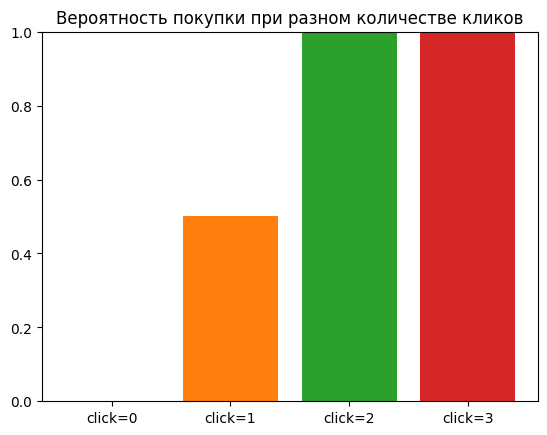

In [26]:
import matplotlib.pyplot as plt

# считаем вероятность покупки для каждого уровня кликов
for click in [0, 1, 2, 3]:
    total = sum(1 for r in records if r["clicked"] == click)
    bought = sum(1 for r in records if r["clicked"] == click and r["bought"] > 0)
    prob = bought / total if total > 0 else 0
    print(f"P(buy|click={click}) = {prob} ({bought}/{total})")
    plt.bar(f"click={click}", prob)

plt.ylim(0, 1)
plt.title("Вероятность покупки при разном количестве кликов")
plt.show()

---
## Ячейка 8/10 — Монте-Карло: проверяем вероятность симуляцией

**Идея Монте-Карло**
Если мы не уверены, можно “прогнать” много случайных экспериментов
и оценить вероятность как частоту.

Сегодня мы сделаем симуляцию:
- случайно генерируем clicked (с вероятностью p_click)
- потом bought зависит от clicked:
  - если clicked=1 → вероятность покупки p_buy_click1
  - если clicked=0 → вероятность покупки p_buy_click0

Это модель “зависимых событий”.


In [27]:
import numpy as np

def simulate_click_buy(n: int, p_click: float, p_buy_click0: float, p_buy_click1: float, seed: int = 42):
    rng = np.random.default_rng(seed)
    clicked = rng.random(n) < p_click
    probs = np.where(clicked, p_buy_click1, p_buy_click0)
    bought = rng.random(n) < probs
    return clicked, bought

clicked_sim, bought_sim = simulate_click_buy(
    n=100_000,
    p_click=0.6,
    p_buy_click0=0.05,
    p_buy_click1=0.25,
    seed=1
)

count_click1 = int(clicked_sim.sum())
count_buy_and_click1 = int((bought_sim & clicked_sim).sum())
p_est = count_buy_and_click1 / count_click1

print("simulated P(buy|click=1) ≈", round(p_est, 3))


simulated P(buy|click=1) ≈ 0.248


---
## Ячейка 9/10 — Гистограмма оценок вероятности (matplotlib)

Симуляция даёт немного разные оценки из-за случайности.
Мы сделаем несколько запусков и построим гистограмму оценок P(buy|click=1).

Это показывает, что вероятность “дрожит” вокруг истинного значения.


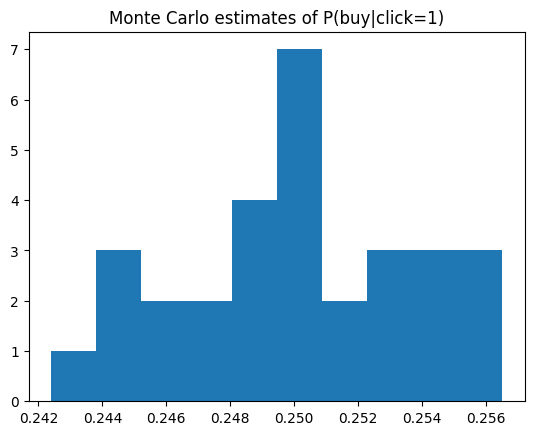

mean estimate = 0.25


In [28]:
def estimate_p_buy_given_click1(n: int, seed: int) -> float:
    clicked_sim, bought_sim = simulate_click_buy(
        n=n, p_click=0.6, p_buy_click0=0.05, p_buy_click1=0.25, seed=seed
    )
    count_click1 = int(clicked_sim.sum())
    count_buy_and_click1 = int((bought_sim & clicked_sim).sum())
    return count_buy_and_click1 / count_click1

estimates = [estimate_p_buy_given_click1(n=20_000, seed=s) for s in range(30)]

plt.hist(estimates, bins=10)
plt.title("Monte Carlo estimates of P(buy|click=1)")
plt.show()

print("mean estimate =", round(float(np.mean(estimates)), 3))


---
## Ячейка 10/10 — Автопроверка (`assert`)

Тесты проверяют:
- корректность P(A) и P(A|B)
- таблицу 2×2
- базовую адекватность симуляции

Запускайте Run all.


In [29]:
# =========================
# BLOCK 04 — LESSON 03 TESTS (НЕ МЕНЯТЬ)
# =========================


def approx(a: float, b: float, eps: float = 1e-6) -> bool:
    return abs(a - b) <= eps

def run_all_tests():
    # используем исходные данные
    recs = records.copy()

    n = len(recs)
    c_click = sum(1 for r in recs if r["clicked"] == 1)
    c_buy = sum(1 for r in recs if r["bought"] == 1)
    c_both = sum(1 for r in recs if r["clicked"] == 1 and r["bought"] == 1)

    assert n == 12
    assert c_click == 2
    assert c_buy == 3
    assert c_both == 1

    assert approx(prob_event(c_click, n), 2/12)
    assert approx(prob_event(c_buy, n), 3/12)
    assert approx(prob_conditional(c_both, c_click), 1/2)

    p_buy = prob_event(c_buy, n)
    p_buy_given_click = prob_conditional(c_both, c_click)
    assert is_independent_by_counts(p_buy, p_buy_given_click, tol=0.05) is False

    # проверка 4x4 таблицы
    t = contingency_4x4(recs, "clicked", "bought")
    expected = [
        [2, 0, 0, 0],
        [1, 1, 0, 0],
        [0, 1, 2, 0],
        [0, 1, 1, 3]
    ]
    assert t == expected

    # проверка симуляции
    clicked_sim, bought_sim = simulate_click_buy(50_000, 0.6, 0.05, 0.25, seed=123)
    count_click1 = int(clicked_sim.sum())
    est = float((bought_sim & clicked_sim).sum()) / count_click1
    assert abs(est - 0.25) < 0.02

    print("✅ BLOCK04 LESSON03: all tests passed")

run_all_tests()

✅ BLOCK04 LESSON03: all tests passed
